# Temporal XGBoost **v3** — RSU-tier (pipeline-aligned)

RSU-tier temporal analyzer, wired to the fusion spine (`ml/fusion/identity_manifest.py`):
same identity subsample, leakage-safe split, and **2 s export grid** as RSSI-CNN v2 / GRU v3 / trust v2.

- Data: the 3 pct-sweep runs (`pct20_s1`, `pct40_s1`, `pct100_s1`), `communication_log.csv` streamed
  memory-safe, filtered to RSU receptions (`receiver_role == "rsu_edge"`).
- Windows: **5 s span / 2 s step** (doc); `window_start_seconds` snapped to the shared 2 s grid.
- Labels: **7-class** `attack_type ∈ {0..6}` (phase-time based, masked by `claimed != real`), softmax.
- Features: **honest behavioural + cross-identity context ONLY** — the RSU RSSI-awareness merge
  (rssi_mismatch_count / verified_probability / state_mismatch / estimated_distance) is the same
  RSSI-position-mismatch signal flagged as simulator leakage, already quantified by the RSSI XGB's
  `rssi_xgb_rsu_docfeat.parquet`, so it is deliberately **not** duplicated here.
- Output: `p̄_temp = 1 − P(legit)` (Eq 3.19) → `notebooks/outputs/temporal_xgb_rsu.parquet`,
  key `[run_id, attack_percentage, claimed_node_id, window_start_seconds, split]`, for the Eq 3.20 RSU ensemble.


## 1. Configuration · RSU tier · fusion spine

In [1]:
import os, json, warnings, random, sys
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)

BASE_DIR = "/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack"

# ── Shared fusion spine (single source of truth): identical identity subsample,
#    leakage-safe split, and 2 s export grid as RSSI-CNN v2 / GRU v3 / trust v2, so this
#    parquet joins on (run_id, attack_percentage, claimed_node_id, window_start_seconds, split).
sys.path.insert(0, f"{BASE_DIR}/ml/fusion")
import identity_manifest as IDM
MAN           = IDM.load_manifest()
RUN_DIRS      = IDM.RUN_DIRS
ARTIFACTS_DIR = str(IDM.ARTIFACTS_DIR)          # notebooks/outputs (contract exports land here)
EXPORT_GRID_S = IDM.EXPORT_GRID_S               # 2.0 s

OUTPUT_DIR = f"{BASE_DIR}/ml/Outputs_Temporal_XGB"   # model/plots (non-contract)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 7-class taxonomy (index == attack_type); phase attack_type 1..6 maps directly to 1..6.
CLASS_NAMES = ["legitimate", "outsider", "sim", "nonsim", "indirect",
               "malicious_rsu", "malicious_controller"]
N_CLASSES   = len(CLASS_NAMES)
NAME_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_NAME = {i: c for c, i in NAME_TO_IDX.items()}
LEGIT = 0

# real_node_id is used ONLY to derive the label (claimed != real); never a model feature.
USE_COLS = ["receive_time", "flow", "receiver_role", "receiver_id", "real_node_id", "claimed_node_id",
            "message_type", "sequence_number", "packet_size", "delay",
            "bsm_temporary_id", "bsm_msg_count", "bsm_x", "bsm_y", "bsm_speed", "bsm_heading"]
RSU_RX_FLOWS = ["v2v_beacon", "v2rsu_report"]

WINDOW_SIZE_S      = 5.0     # doc: 5 s aggregation span
WINDOW_STEP_S      = 2.0     # doc: 2 s step == shared export grid
MIN_BEACONS_WINDOW = 2

SWEEP_MAX_DEPTH = [4, 5, 6]
XGB_LR = 0.05; XGB_N_EST = 600; XGB_EARLY_STOP = 30


def assign_attack_type(times, phase_df):
    """Phase attack_type (1..6) per beacon time; 0 before the first phase.
    Matches RSSI-CNN v2 / trust_v2 (searchsorted on phase start_time)."""
    starts = phase_df["start_time"].to_numpy(dtype=float)
    types  = phase_df["attack_type"].to_numpy()
    idx = np.searchsorted(starts, np.asarray(times, dtype=float), side="right") - 1
    out = np.zeros(len(idx), dtype=np.int64); ok = idx >= 0
    out[ok] = types[idx[ok]]
    return out


def full_proba(model, X):
    """predict_proba padded to a fixed (N, 7) matrix regardless of which classes the model
    saw in training (classes 5/6 are ~absent at the vehicle/RSU-beacon tier)."""
    p = model.predict_proba(X)
    full = np.zeros((len(X), N_CLASSES), dtype=np.float32)
    for j, c in enumerate(model.classes_):
        full[:, int(c)] = p[:, j]
    return full


print("runs  :", [os.path.basename(r) for r in RUN_DIRS])
print("window:", WINDOW_SIZE_S, "s /", WINDOW_STEP_S, "s step  (grid", EXPORT_GRID_S, "s)")

runs  : ['pct100_s1', 'pct20_s1', 'pct40_s1']
window: 5.0 s / 2.0 s step  (grid 2.0 s)


## 2. Feature builders (behavioural + RSU cross-identity context)

Reused verbatim from v2.1: `shannon_entropy`, `build_global_context`, and `build_feature_table` (31 features per `(claimed_node_id, 5 s window)`, including the cross-identity context only an RSU can see). Labels are carried as the class NAME in `attack_class` and aggregated per window into `attack_type`.

In [2]:
def shannon_entropy(values, n_bins=10):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2: return np.nan
    rng = values.max() - values.min()
    if rng <= 1e-12: return 0.0
    counts, _ = np.histogram(values, bins=n_bins, range=(values.min(), values.max()))
    probs = counts / counts.sum(); probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))

def build_global_context(b_sorted, window_size, window_step):
    """Cross-identity context per global time window — only computable at RSU tier."""
    t   = b_sorted["receive_time"].values
    cid = b_sorted["claimed_node_id"].values
    tid = b_sorted["bsm_temporary_id"].values
    first_seen = b_sorted.groupby("claimed_node_id")["receive_time"].min().values
    t0, t1 = float(t.min()), float(t.max())
    starts = np.arange(np.floor(t0), t1 + window_step, window_step)
    ctx = {}
    for s in starts:
        e = s + window_size
        lo = np.searchsorted(t, s); hi = np.searchsorted(t, e)
        if hi <= lo:
            ctx[round(float(s),6)] = (0,0,0,0,0); continue
        sub = pd.DataFrame({"cid": cid[lo:hi], "tid": tid[lo:hi]})
        claimed_per_temp = sub.groupby("tid")["cid"].nunique()
        new_ids = int(((first_seen >= s) & (first_seen < e)).sum())
        ctx[round(float(s),6)] = (
            int(sub["cid"].nunique()), int(sub["tid"].nunique()),
            int((claimed_per_temp > 1).sum()),
            int(claimed_per_temp.max()) if len(claimed_per_temp) else 0, new_ids)
    return ctx, starts

def build_feature_table(beacons_df, window_size=WINDOW_SIZE_S, window_step=WINDOW_STEP_S,
                        min_beacons=MIN_BEACONS_WINDOW):
    b = beacons_df.sort_values("receive_time").reset_index(drop=True)
    context, starts = build_global_context(b, window_size, window_step)
    first_seen_global = b.groupby("claimed_node_id")["receive_time"].min().to_dict()
    rows = []
    for cidv, g in b.groupby("claimed_node_id"):
        g = g.sort_values("receive_time").reset_index(drop=True)
        gt0, gt1 = g["receive_time"].min(), g["receive_time"].max()
        fs = first_seen_global[cidv]
        rel = starts[(starts <= gt1) & (starts + window_size > gt0)]
        prev_end = None
        for s in rel:
            e = s + window_size
            w = g[(g["receive_time"] >= s) & (g["receive_time"] < e)]
            if len(w) < min_beacons: continue
            iats = np.diff(w["receive_time"].values)
            tids = w["bsm_temporary_id"].astype(str).values
            tch  = max(int((tids[1:] != tids[:-1]).sum()), 0) if len(tids) > 1 else 0
            gap  = (s - prev_end) if prev_end is not None else 0.0
            beacons_so_far = int((g["receive_time"] < e).sum())
            dx = np.diff(w["bsm_x"].values); dy = np.diff(w["bsm_y"].values)
            sp = w["bsm_speed"].values
            exp_dx = sp[:-1] * np.cos(np.radians(w["bsm_heading"].values[:-1])) * iats if len(iats) else np.array([0.])
            exp_dy = sp[:-1] * np.sin(np.radians(w["bsm_heading"].values[:-1])) * iats if len(iats) else np.array([0.])
            speed_err = np.sqrt((dx - exp_dx)**2 + (dy - exp_dy)**2).mean() if len(dx) else 0.0
            ctx_key = min(context.keys(), key=lambda k: abs(k - round(float(s),6)))
            ac, at, st, mc, ni = context[ctx_key]
            msg_counts = w["bsm_msg_count"].values
            rows.append({
                "claimed_node_id": cidv, "window_start": float(s), "window_end": float(e),
                "attack_type": w["attack_class"].mode().iloc[0],
                "is_sybil": int(w["is_sybil"].mode().iloc[0]),
                "n_beacons": len(w),
                "n_distinct_temp_ids": int(w["bsm_temporary_id"].nunique()),
                "temp_id_churn_rate": tch / max(len(tids)-1, 1),
                "temp_id_change_count": tch,
                "claimed_id_age_s": float(s) - fs,
                "claimed_id_beacons_seen_so_far": beacons_so_far,
                "iat_mean": float(iats.mean()) if len(iats) else 0.0,
                "iat_std":  float(iats.std())  if len(iats) else 0.0,
                "iat_min":  float(iats.min())  if len(iats) else 0.0,
                "iat_max":  float(iats.max())  if len(iats) else 0.0,
                "iat_entropy": shannon_entropy(iats),
                "gap_since_prev_window": gap,
                "beacon_rate_hz": len(w) / window_size,
                "pos_x_var": float(w["bsm_x"].var()),
                "pos_y_var": float(w["bsm_y"].var()),
                "speed_mean": float(sp.mean()),
                "speed_std":  float(sp.std()),
                "heading_std": float(w["bsm_heading"].std()),
                "speed_consistency_err_mean": speed_err,
                "packet_size_mean": float(w["packet_size"].mean()),
                "delay_mean": float(w["delay"].mean()),
                "delay_std":  float(w["delay"].std()),
                "observer_count_mean": float(w["observer_count"].mean()),
                "observer_count_std":  float(w["observer_count"].std()),
                "msg_count_span": int(msg_counts.max() - msg_counts.min()) if len(msg_counts) > 1 else 0,
                "msg_count_reset_flag": int((np.diff(msg_counts) < 0).any()) if len(msg_counts) > 1 else 0,
                # Cross-identity context — ONLY computable at RSU tier
                "active_claimed_ids_window": ac,
                "active_temp_ids_window": at,
                "shared_temp_id_count_window": st,
                "max_claimed_per_temp_id_window": mc,
                "new_claimed_ids_window": ni,
            })
            prev_end = e
    return pd.DataFrame(rows)


## 3. Load + label (7-class) + window each pct-sweep run (memory-safe)

`communication_log.csv` (~12 GB/run) is streamed in chunks, keeping only RSU receptions for the shared identity subsample. Cross-identity context is built per run, then rows are tagged with `run_id`/`attack_percentage`, snapped to the 2 s grid, and given the shared split.

In [3]:
BEACON_KEY = ["real_node_id", "claimed_node_id", "bsm_temporary_id", "receive_time"]

def dedup_beacons(df):
    """Collapse RSU broadcast fan-out. observer_count = #RSUs that overheard the beacon."""
    dup = (df.groupby(BEACON_KEY)["receiver_id"].nunique()
             .rename("observer_count").reset_index())
    agg_cols = [c for c in df.columns if c not in ["receiver_id", "receiver_role"]]
    b = df.sort_values("receive_time").groupby(BEACON_KEY, as_index=False)[agg_cols].first()
    b = b.merge(dup, on=BEACON_KEY, how="left")
    return b.sort_values(["claimed_node_id", "receive_time"]).reset_index(drop=True)

def _rsu_rows(chunk):
    return (chunk["receiver_role"] == "rsu_edge") & (chunk["flow"].isin(RSU_RX_FLOWS))

# Per-run pipeline: stream RSU receptions -> dedup -> 7-class label -> windowed features.
# claimed_node_ids collide across runs, so the cross-identity context is built per run and the
# rows are tagged with run_id before concatenation.
parts = []
for run_dir in RUN_DIRS:
    meta   = json.load(open(f"{run_dir}/run_meta.json"))
    run_id = str(meta.get("run_id", os.path.basename(run_dir)))
    pct    = int(meta["sybil_attack_percentage"])
    ph     = next(p for p in os.listdir(run_dir) if p.startswith("attack_phases"))
    phases = pd.read_csv(f"{run_dir}/{ph}").sort_values("start_time")
    print(f"[{run_id}] pct{pct} — streaming communication_log (RSU rows only) ...")
    df = IDM.read_run_log_filtered(f"{run_dir}/communication_log.csv", USE_COLS,
                                   "claimed_node_id", run_id, MAN, extra_filter=_rsu_rows)
    if not len(df):
        print("    (no RSU rows kept for this run)"); continue
    b = dedup_beacons(df); del df
    is_sybil = (b["real_node_id"] != b["claimed_node_id"]).astype(int).values
    lab = np.where(is_sybil == 1, assign_attack_type(b["receive_time"].values, phases), 0)
    b["attack_class"] = [CLASS_NAMES[int(k)] for k in lab]   # build_feature_table takes class NAME
    b["is_sybil"]     = is_sybil
    fdf = build_feature_table(b); del b
    fdf["run_id"] = run_id; fdf["attack_percentage"] = pct
    print(f"    -> {len(fdf):,} windows  ({int(fdf.is_sybil.sum()):,} sybil, "
          f"{fdf.claimed_node_id.nunique()} ids)")
    parts.append(fdf)

feature_df_rsu = pd.concat(parts, ignore_index=True)
feature_df_rsu = feature_df_rsu.rename(columns={"window_start": "window_start_seconds"})
feature_df_rsu["window_start_seconds"] = IDM.snap_grid(feature_df_rsu["window_start_seconds"])

# shared leakage-safe split (grouped by real vehicle in the manifest); inner-join drops
# any (run_id, claimed_node_id) outside the subsample.
feature_df_rsu = IDM.attach_split(feature_df_rsu, MAN)
print("\ntotal windows:", len(feature_df_rsu),
      "| split:", feature_df_rsu["split"].value_counts().to_dict())
print("class dist:",
      {k: int(v) for k, v in feature_df_rsu["attack_type"].value_counts().items()})

[pct100_s1] pct100 — streaming communication_log (RSU rows only) ...
    [safe-read] communication_log.csv: scanned 55,648,149 rows, kept 793,212 (1.4%)
    -> 8,477 windows  (3,379 sybil, 426 ids)
[pct20_s1] pct20 — streaming communication_log (RSU rows only) ...
    [safe-read] communication_log.csv: scanned 64,372,236 rows, kept 663,599 (1.0%)
    -> 6,239 windows  (1,566 sybil, 193 ids)
[pct40_s1] pct40 — streaming communication_log (RSU rows only) ...
    [safe-read] communication_log.csv: scanned 62,635,678 rows, kept 723,555 (1.2%)
    -> 7,762 windows  (2,891 sybil, 294 ids)

total windows: 22478 | split: {'train': 15363, 'test': 4092, 'val': 3023}
class dist: {'legitimate': 14642, 'sim': 2629, 'outsider': 2452, 'indirect': 1383, 'nonsim': 1222, 'malicious_rsu': 150}


## 4. Split masks + 7-class labels (honest behavioural features)

In [4]:
# Honest RSU-observable behavioural + cross-identity context features (31).
BEHAVIOURAL_COLS = [
    "n_beacons", "n_distinct_temp_ids", "temp_id_churn_rate", "temp_id_change_count",
    "claimed_id_age_s", "claimed_id_beacons_seen_so_far",
    "iat_mean", "iat_std", "iat_min", "iat_max", "iat_entropy",
    "gap_since_prev_window", "beacon_rate_hz", "pos_x_var", "pos_y_var",
    "speed_mean", "speed_std", "heading_std", "speed_consistency_err_mean",
    "packet_size_mean", "delay_mean", "delay_std", "observer_count_mean", "observer_count_std",
    "msg_count_span", "msg_count_reset_flag",
    "active_claimed_ids_window", "active_temp_ids_window", "shared_temp_id_count_window",
    "max_claimed_per_temp_id_window", "new_claimed_ids_window",
]
FEATURES = BEHAVIOURAL_COLS
assert "real_node_id" not in FEATURES, "real_node_id leaked!"

tr = (feature_df_rsu["split"] == "train").values
va = (feature_df_rsu["split"] == "val").values
te = (feature_df_rsu["split"] == "test").values
y  = feature_df_rsu["attack_type"].map(NAME_TO_IDX).astype(int).values

print(f"features: {len(FEATURES)} behavioural (+cross-identity)")
print(f"train {tr.sum():,}   val {va.sum():,}   test {te.sum():,}")

features: 31 behavioural (+cross-identity)
train 15,363   val 3,023   test 4,092


## 5. Train 7-class XGBoost (max_depth ∈ {4,5,6}, early stop on val MCC)

In [5]:
import xgboost as xgb
from sklearn.metrics import (matthews_corrcoef, f1_score, accuracy_score,
                             classification_report, confusion_matrix, recall_score)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

def make_xgb(max_depth):
    # objective/num_class inferred from the labels present; XGB handles NaN natively,
    # so no median-impute / standard-scale step is needed for trees.
    return xgb.XGBClassifier(
        max_depth=max_depth, learning_rate=XGB_LR, n_estimators=XGB_N_EST,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=4,
        reg_lambda=1.0, reg_alpha=0.1, random_state=RANDOM_SEED,
        tree_method="hist", early_stopping_rounds=XGB_EARLY_STOP)

Xtr, Xva, Xte = feature_df_rsu.loc[tr, FEATURES], feature_df_rsu.loc[va, FEATURES], feature_df_rsu.loc[te, FEATURES]
ytr, yva, yte = y[tr], y[va], y[te]
sw = compute_sample_weight("balanced", ytr)

best_mcc, best_depth, rsu_xgb = -1.0, None, None
print("max_depth sensitivity sweep (paper §4.10.5):")
for depth in SWEEP_MAX_DEPTH:
    m = make_xgb(depth)
    m.fit(Xtr, ytr, sample_weight=sw, eval_set=[(Xva, yva)], verbose=False)
    vmcc = matthews_corrcoef(yva, m.predict(Xva))
    print(f"  max_depth={depth}: val MCC={vmcc:.4f}  best_iter={m.best_iteration}")
    if vmcc > best_mcc:
        best_mcc, best_depth, rsu_xgb = vmcc, depth, m
print(f"\nselected max_depth={best_depth}  (val MCC={best_mcc:.4f})")

max_depth sensitivity sweep (paper §4.10.5):
  max_depth=4: val MCC=0.9658  best_iter=585
  max_depth=5: val MCC=0.9622  best_iter=520
  max_depth=6: val MCC=0.9640  best_iter=598

selected max_depth=4  (val MCC=0.9658)


## 6. Evaluate (7-class + sybil-vs-legit view)

=== RSU temporal XGB (test) ===  MCC=0.9660  acc=0.9807  f1_macro=0.9133  | sybil recall=0.9888  FPR=0.0027

                      precision    recall  f1-score   support

          legitimate      0.993     0.997     0.995      2569
            outsider      0.995     0.969     0.982       448
                 sim      0.951     0.964     0.958       526
              nonsim      0.972     0.954     0.963       219
            indirect      0.958     0.942     0.950       294
       malicious_rsu      0.600     0.667     0.632        36
malicious_controller      0.000     0.000     0.000         0

            accuracy                          0.981      4092
           macro avg      0.782     0.785     0.783      4092
        weighted avg      0.981     0.981     0.981      4092



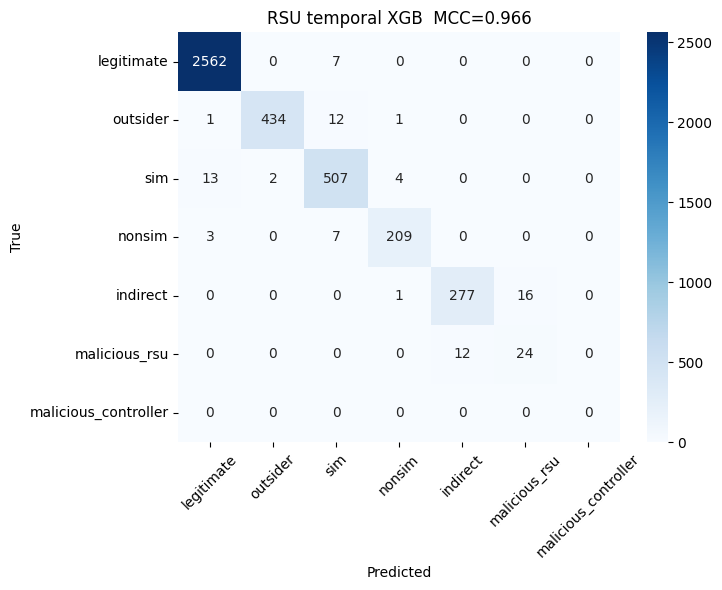


Top-15 feature importances:
speed_consistency_err_mean        0.194398
iat_min                           0.103931
iat_entropy                       0.095647
pos_x_var                         0.071198
n_beacons                         0.050568
claimed_id_beacons_seen_so_far    0.048927
claimed_id_age_s                  0.045751
active_claimed_ids_window         0.041317
packet_size_mean                  0.039517
iat_std                           0.032069
beacon_rate_hz                    0.031701
new_claimed_ids_window            0.031137
active_temp_ids_window            0.028997
iat_max                           0.028273
iat_mean                          0.024089
dtype: float32


In [6]:
pred = rsu_xgb.predict(Xte)
test_mcc = matthews_corrcoef(yte, pred)
test_acc = accuracy_score(yte, pred)
test_f1  = f1_score(yte, pred, average="macro", zero_division=0)
bt, bp = (yte != 0).astype(int), (pred != 0).astype(int)          # sybil-vs-legit view
tn = int(((bt == 0) & (bp == 0)).sum()); fp = int(((bt == 0) & (bp == 1)).sum())
fpr = fp / max(tn + fp, 1)
print(f"=== RSU temporal XGB (test) ===  MCC={test_mcc:.4f}  acc={test_acc:.4f}  "
      f"f1_macro={test_f1:.4f}  | sybil recall={recall_score(bt, bp):.4f}  FPR={fpr:.4f}\n")
print(classification_report(yte, pred, labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

cm = confusion_matrix(yte, pred, labels=list(range(N_CLASSES)))
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title=f"RSU temporal XGB  MCC={test_mcc:.3f}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/temporal_xgb_cm.png", dpi=150); plt.show()

print("\nTop-15 feature importances:")
print(pd.Series(rsu_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15))

## 7. Export on-contract parquet (`p̄_temp = 1 − P(legit)`, Eq 3.19)

In [7]:
# p_bar_temp(v_i) = 1 − P(class=legit | v_i), scored over ALL windows, on the shared join key
# so the RSU ensemble (Eq 3.20) can fuse per window with p_bar_rssi and y_hat_i.
KEY = ["run_id", "attack_percentage", "claimed_node_id", "window_start_seconds", "split"]
fp_all = full_proba(rsu_xgb, feature_df_rsu[FEATURES])

out = feature_df_rsu[KEY].copy()
out["attack_type"] = y
out["is_sybil"]    = feature_df_rsu["is_sybil"].values
out["p_bar_temp"]  = (1.0 - fp_all[:, LEGIT]).astype(np.float32)
for k in range(N_CLASSES):
    out[f"p_temp_xgb_{k}"] = fp_all[:, k].astype(np.float32)   # distinct from GRU's p_temp_k

assert not out.duplicated(subset=KEY).any(), "duplicate join keys in export"
path = f"{ARTIFACTS_DIR}/temporal_xgb_rsu.parquet"
out.to_parquet(path, index=False)
print(f"wrote {path}  {out.shape}  mean p_bar_temp={out.p_bar_temp.mean():.3f}")
out.head(3)

wrote /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/notebooks/outputs/temporal_xgb_rsu.parquet  (22478, 15)  mean p_bar_temp=0.349


,run_id,attack_percentage,claimed_node_id,window_start_seconds,split,attack_type,is_sybil,p_bar_temp,p_temp_xgb_0,p_temp_xgb_1,p_temp_xgb_2,p_temp_xgb_3,p_temp_xgb_4,p_temp_xgb_5,p_temp_xgb_6
0,pct100_s1,100,8,50.0,test,0,0,0.001216,0.998784,0.000009,0.001139,6.553470e-05,1.770112e-06,1.146473e-07,0.0
1,pct100_s1,100,8,52.0,test,0,0,0.000875,0.999125,0.000010,0.000864,1.402329e-07,2.671319e-07,5.053201e-08,0.0
2,pct100_s1,100,8,54.0,test,0,0,0.000265,0.999735,0.000009,0.000255,5.386464e-08,1.771518e-07,4.514418e-08,0.0


## 8. Save model & results

In [8]:
rsu_xgb.save_model(f"{OUTPUT_DIR}/temporal_xgb_rsu.json")
summary = {
    "model": "XGBoost_RSU_temporal_7class_v3",
    "window_sec": WINDOW_SIZE_S, "step_sec": WINDOW_STEP_S,
    "n_windows": int(len(feature_df_rsu)),
    "runs": feature_df_rsu["run_id"].value_counts().to_dict(),
    "n_features": len(FEATURES), "features": FEATURES,
    "best_depth": int(best_depth), "val_mcc": float(best_mcc),
    "test_mcc": float(test_mcc), "test_acc": float(test_acc),
    "test_f1_macro": float(test_f1), "test_fpr": float(fpr),
}
with open(f"{OUTPUT_DIR}/temporal_xgb_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=== OUTPUTS ===")
for p in [f"{ARTIFACTS_DIR}/temporal_xgb_rsu.parquet",
          f"{OUTPUT_DIR}/temporal_xgb_rsu.json",
          f"{OUTPUT_DIR}/temporal_xgb_results.json",
          f"{OUTPUT_DIR}/temporal_xgb_cm.png"]:
    print(f"  [{'OK' if os.path.exists(p) else 'MISSING'}]  {p}")
print("\nNext: fl/rsu_ensemble_fusion.py combines y_hat_i (Eq 3.18) + p_bar_temp + p_bar_rssi -> y_hat_ens (Eq 3.20).")

=== OUTPUTS ===
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/notebooks/outputs/temporal_xgb_rsu.parquet
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_Temporal_XGB/temporal_xgb_rsu.json
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_Temporal_XGB/temporal_xgb_results.json
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_Temporal_XGB/temporal_xgb_cm.png

Next: fl/rsu_ensemble_fusion.py combines y_hat_i (Eq 3.18) + p_bar_temp + p_bar_rssi -> y_hat_ens (Eq 3.20).


## Note — window size

The **5 s / 2 s** window is the doc's choice and aligns with the shared 2 s export grid (5 s = aggregation span, 2 s = step = grid). The window-size sensitivity sweep (§4.10.5) from `temporal_xgb_seq_v2.1.ipynb` still stands as the empirical justification; it is omitted here to keep the aligned pipeline lean.